<a href="https://colab.research.google.com/github/preetam-coder/Calculator/blob/main/Car_Price_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [43]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Lasso
from sklearn import metrics
import numpy as np

Data collection and processing

In [4]:
car_dataset=pd.read_csv('car data.csv')

In [5]:
car_dataset.head()

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


In [6]:
car_dataset.shape

(301, 9)

In [7]:
car_dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    object 
 1   Year           301 non-null    int64  
 2   Selling_Price  301 non-null    float64
 3   Present_Price  301 non-null    float64
 4   Kms_Driven     301 non-null    int64  
 5   Fuel_Type      301 non-null    object 
 6   Seller_Type    301 non-null    object 
 7   Transmission   301 non-null    object 
 8   Owner          301 non-null    int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 21.3+ KB


In [8]:
car_dataset.isnull().sum()

,0
Car_Name,0
Year,0
Selling_Price,0
Present_Price,0
Kms_Driven,0
Fuel_Type,0
Seller_Type,0
Transmission,0
Owner,0


In [10]:
print(car_dataset.Fuel_Type.value_counts())
print(car_dataset.Seller_Type.value_counts())
print(car_dataset.Transmission.value_counts())

Fuel_Type
Petrol    239
Diesel     60
CNG         2
Name: count, dtype: int64
Seller_Type
Dealer        195
Individual    106
Name: count, dtype: int64
Transmission
Manual       261
Automatic     40
Name: count, dtype: int64


ENCODING THE CATEGORICAL DATA

In [16]:
car_dataset.replace({'Fuel_Type':{'Petrol':0,'Diesel':1,'CNG':2}},inplace=True)
car_dataset.replace({'Seller_Type':{'Dealer':0,'Individual':1}},inplace=True)
car_dataset.replace({'Transmission':{'Manual':0,'Automatic':1}},inplace=True)

In [17]:
car_dataset.head()

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,0,0,0,0
1,sx4,2013,4.75,9.54,43000,1,0,0,0
2,ciaz,2017,7.25,9.85,6900,0,0,0,0
3,wagon r,2011,2.85,4.15,5200,0,0,0,0
4,swift,2014,4.60,6.87,42450,1,0,0,0


splitting the data into training data and test data

In [18]:
x=car_dataset.drop(['Car_Name','Selling_Price'],axis=1)
y=car_dataset['Selling_Price']

In [19]:
print(x)

     Year  Present_Price  Kms_Driven  ...  Seller_Type  Transmission  Owner
0    2014           5.59       27000  ...            0             0      0
1    2013           9.54       43000  ...            0             0      0
2    2017           9.85        6900  ...            0             0      0
3    2011           4.15        5200  ...            0             0      0
4    2014           6.87       42450  ...            0             0      0
..    ...            ...         ...  ...          ...           ...    ...
296  2016          11.60       33988  ...            0             0      0
297  2015           5.90       60000  ...            0             0      0
298  2009          11.00       87934  ...            0             0      0
299  2017          12.50        9000  ...            0             0      0
300  2016           5.90        5464  ...            0             0      0

[301 rows x 7 columns]


In [20]:
print(y)

0       3.35
1       4.75
2       7.25
3       2.85
4       4.60
       ...  
296     9.50
297     4.00
298     3.35
299    11.50
300     5.30
Name: Selling_Price, Length: 301, dtype: float64


splitting training and test data

In [21]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.1,random_state=2)

model training


lasso regression

prediction on training data

In [34]:
training_data_prediction = lasso_reg_model.predict(x_train)
error_score = metrics.r2_score(y_train, training_data_prediction)
print("R squared Error for Training Data (Lasso): ", error_score)

R squared Error for Training Data (Lasso):  0.8427856123435794


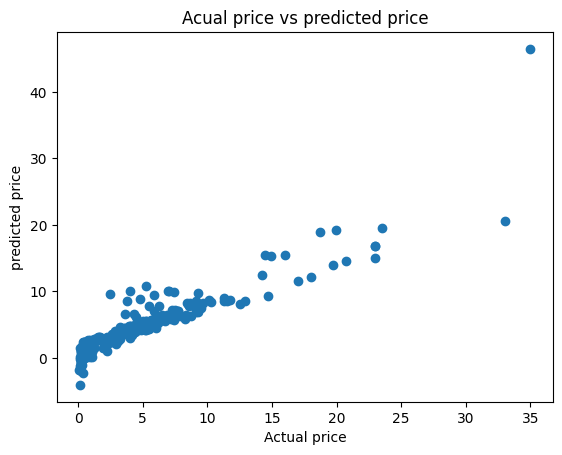

In [35]:
plt.scatter(y_train, training_data_prediction)
plt.xlabel("Actual price")
plt.ylabel("predicted price")
plt.title("Acual price vs predicted price")
plt.show()

prediction on test data

In [38]:
lasso_reg_model = Lasso()
lasso_reg_model.fit(x_train, y_train)
test_data_prediction = lasso_reg_model.predict(x_test)
error_score = metrics.r2_score(y_test, test_data_prediction)
print("R squared Error for Test Data (Lasso): ", error_score)

R squared Error for Test Data (Lasso):  0.8709167941173195


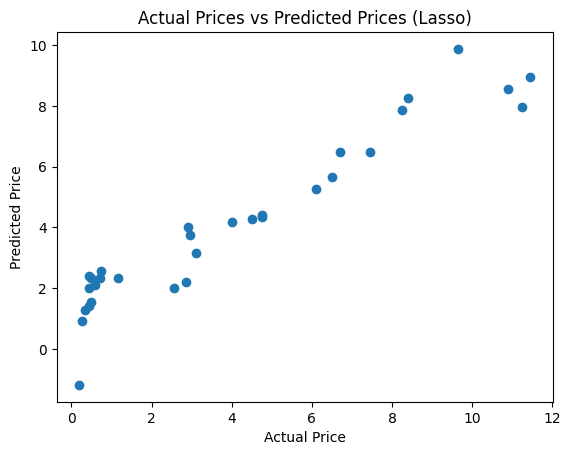

In [39]:
plt.scatter(y_test, test_data_prediction)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual Prices vs Predicted Prices (Lasso)")
plt.show()

prediction on test data (linear regression)

R squared Error for Test Data (Linear Regression):  0.8365766715027051


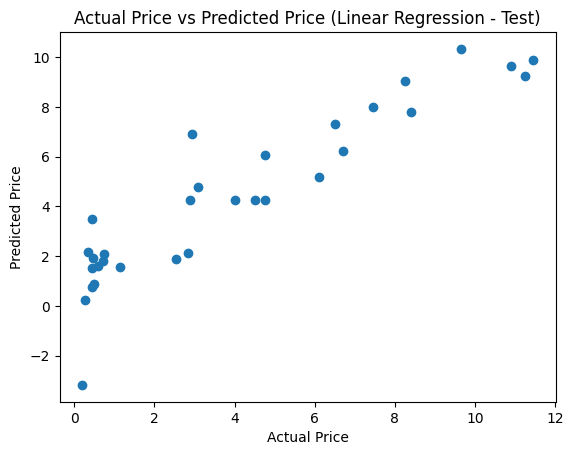

In [41]:
test_data_prediction_lr = lin_reg_model.predict(x_test)
error_score_lr_test = metrics.r2_score(y_test, test_data_prediction_lr)
print("R squared Error for Test Data (Linear Regression): ", error_score_lr_test)

# Scatter plot
plt.scatter(y_test, test_data_prediction_lr)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual Price vs Predicted Price (Linear Regression - Test)")
plt.show()

prdiction on training data (linear regression

R squared Error for Training Data (Linear Regression):  0.8799451660493711


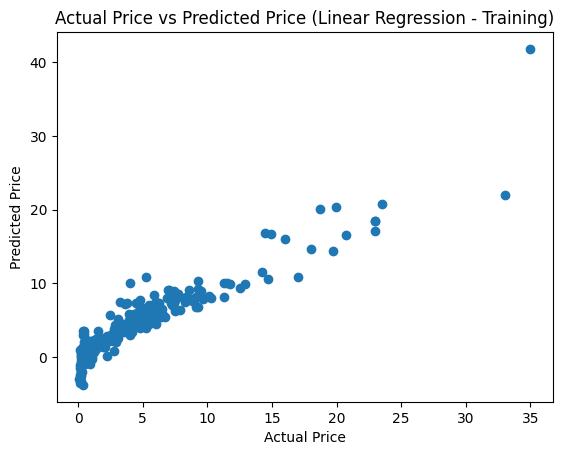

In [40]:
training_data_prediction_lr = lin_reg_model.predict(x_train)
error_score_lr_train = metrics.r2_score(y_train, training_data_prediction_lr)
print("R squared Error for Training Data (Linear Regression): ", error_score_lr_train)

# Scatter plot
plt.scatter(y_train, training_data_prediction_lr)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual Price vs Predicted Price (Linear Regression - Training)")
plt.show()

In [44]:
# Evaluate Linear Regression model on test data
mae_lr = metrics.mean_absolute_error(y_test, test_data_prediction_lr)
mse_lr = metrics.mean_squared_error(y_test, test_data_prediction_lr)
rmse_lr = np.sqrt(mse_lr)

print("Linear Regression - Test Data Evaluation:")
print("Mean Absolute Error (MAE):", mae_lr)
print("Mean Squared Error (MSE):", mse_lr)
print("Root Mean Squared Error (RMSE):", rmse_lr)

print("-" * 30)

# Evaluate Lasso Regression model on test data
mae_lasso = metrics.mean_absolute_error(y_test, test_data_prediction)
mse_lasso = metrics.mean_squared_error(y_test, test_data_prediction)
rmse_lasso = np.sqrt(mse_lasso)

print("Lasso Regression - Test Data Evaluation:")
print("Mean Absolute Error (MAE):", mae_lasso)
print("Mean Squared Error (MSE):", mse_lasso)
print("Root Mean Squared Error (RMSE):", rmse_lasso)

Linear Regression - Test Data Evaluation:
Mean Absolute Error (MAE): 1.1516382156613783
Mean Squared Error (MSE): 2.1501299189836294
Root Mean Squared Error (RMSE): 1.4663321311979867
------------------------------
Lasso Regression - Test Data Evaluation:
Mean Absolute Error (MAE): 1.0507413774170433
Mean Squared Error (MSE): 1.6983234006965484
Root Mean Squared Error (RMSE): 1.3031973759552113
